# Final semantic CSV analysis

최종 산출물인 `stay_manual_semantic_clean.csv`, `visa_manual_semantic_clean.csv`만 읽어 구조, 분포, 누락률, 주요 코드/항목을 확인합니다.

이 노트북은 `matplotlib` 기반 시각화를 사용합니다. PDF page, evidence, raw, review 컬럼은 최종 CSV에 없다는 전제를 검증합니다.

In [2]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'data' / 'processed').exists():
    ROOT = (Path.cwd() / '..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
FIG_DIR = ROOT / 'output' / 'figures'
QUALITY_DIR = ROOT / 'output' / 'quality'
REVIEW_DIR = ROOT / 'output' / 'review'
FIG_DIR.mkdir(parents=True, exist_ok=True)
QUALITY_DIR.mkdir(parents=True, exist_ok=True)
REVIEW_DIR.mkdir(parents=True, exist_ok=True)

stay_path = PROCESSED / 'stay_manual_semantic_clean.csv'
visa_path = PROCESSED / 'visa_manual_semantic_clean.csv'

stay = pd.read_csv(stay_path, dtype=str).fillna('')
visa = pd.read_csv(visa_path, dtype=str).fillna('')

font_path = Path('/System/Library/Fonts/Supplemental/AppleGothic.ttf')
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = fm.FontProperties(fname=str(font_path)).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'

print(stay_path, stay.shape)
print(visa_path, visa.shape)

/Users/junghwan/Desktop/Vizabridge/data/processed/stay_manual_semantic_clean.csv (3434, 27)
/Users/junghwan/Desktop/Vizabridge/data/processed/visa_manual_semantic_clean.csv (2311, 28)


## 1. 최종 CSV 계약 확인

금지 컬럼이 없는지, `data/processed`에 최종 CSV 2개만 남았는지 확인합니다.

In [5]:
forbidden_tokens = ['page', 'raw', 'evidence', 'review', 'section_path']
processed_files = sorted(p.name for p in PROCESSED.iterdir() if p.is_file())

contract = []
for name, df in [('체류민원', stay), ('사증민원', visa)]:
    forbidden_cols = [c for c in df.columns if any(token in c for token in forbidden_tokens)]
    contract.append({
        'manual': name,
        'rows': len(df),
        'columns': len(df.columns),
        'forbidden_columns': ', '.join(forbidden_cols),
        'noise_title_rows': int(df['section_title'].isin(['目 次', '목차', '▶ 목차', '▣ 목차']).sum()),
        'document_rows': int((df[['common_documents', 'mandatory_documents', 'other_documents']].apply(lambda s: s.str.strip() != '').any(axis=1)).sum()),
    })

display(pd.DataFrame(contract))
print('processed files:', processed_files)

,manual,rows,columns,forbidden_columns,noise_title_rows,document_rows
0,체류민원,3434,27,,0,1058
1,사증민원,2311,28,,0,752


processed files: ['.gitkeep', 'stay_manual_semantic_clean.csv', 'visa_manual_semantic_clean.csv']


## 2. 분석용 통합 데이터프레임

In [8]:
stay_plot = stay.copy()
stay_plot['manual'] = '체류민원'
stay_plot['code'] = stay_plot['stay_status_code'].replace('', '공통/무코드')

visa_plot = visa.copy()
visa_plot['manual'] = '사증민원'
visa_plot['code'] = visa_plot['visa_code'].replace('', '공통/무코드')

common_analysis_cols = [
    'manual', 'item_type', 'subsection_type', 'petition_type', 'code', 'section_title',
    'common_documents', 'mandatory_documents', 'other_documents',
    'eligibility', 'target_persons', 'requirements', 'procedure',
    'restrictions', 'exceptions', 'fees', 'duration_or_validity',
    'quota_or_limit', 'score_criteria', 'table_rows', 'normalized_text',
]
combined = pd.concat([stay_plot[common_analysis_cols], visa_plot[common_analysis_cols]], ignore_index=True)
combined.head()

,manual,item_type,subsection_type,petition_type,code,section_title,common_documents,mandatory_documents,other_documents,eligibility,...,requirements,procedure,restrictions,exceptions,fees,duration_or_validity,quota_or_limit,score_criteria,table_rows,normalized_text
0,체류민원,stay_status_rule,기타,,공통/무코드,외국인체류 안내매뉴얼,,,,,...,,,,,,,,,,# 외국인체류 안내매뉴얼; 24. 5.; 법무부; 출입국·외국인정책본부
1,체류민원,required_documents,제출서류,,공통/무코드,각종 체류허가 신청 시 유의사항 체류자격별 대상 및 제출서류 등 안내매뉴얼,,각종 체류허가 신청 시 유의사항 체류자격별 대상 및 제출서류 등 안내매뉴얼; 공통사...,,,...,,,,,,,,,각종 체류허가 신청 시 유의사항 체류자격별 대상 및 제출서류 등 안내매뉴얼; 공통사...,각종 체류허가 신청 시 유의사항 체류자격별 대상 및 제출서류 등 안내매뉴얼; 공통사...
2,체류민원,stay_status_rule,기타,,D-9,17. 무역경영(D-9),,,,,...,,,,,,,,,"무역경영(D-9); 외국국적동포 관련; (C-3-8, F-1, H-2, F-4, F-5)","무역경영(D-9); 외국국적동포 관련; (C-3-8, F-1, H-2, F-4, F-5)"
3,체류민원,stay_status_rule,기타,,E-1,19. 교수(E-1),,,,,...,,,,,,,,,교수(E-1); 국내 성장 기반 외국인 청소년; 취업·정주 체류제도,교수(E-1); 국내 성장 기반 외국인 청소년; 취업·정주 체류제도
4,체류민원,required_documents,제출서류,,공통/무코드,유 의 사 항,,# 유 의 사 항; ※ 출입국·외국인청(사무소·출장소)장은 심사를 위해 특히 필요하...,,,...,,,,,,,,,,# 유 의 사 항; ※ 출입국·외국인청(사무소·출장소)장은 심사를 위해 특히 필요하...


## 3. Matplotlib 대시보드

row 수, item type, subsection type, 주요 코드, 서류 필드, 주요 필드 채움률을 한 번에 봅니다.

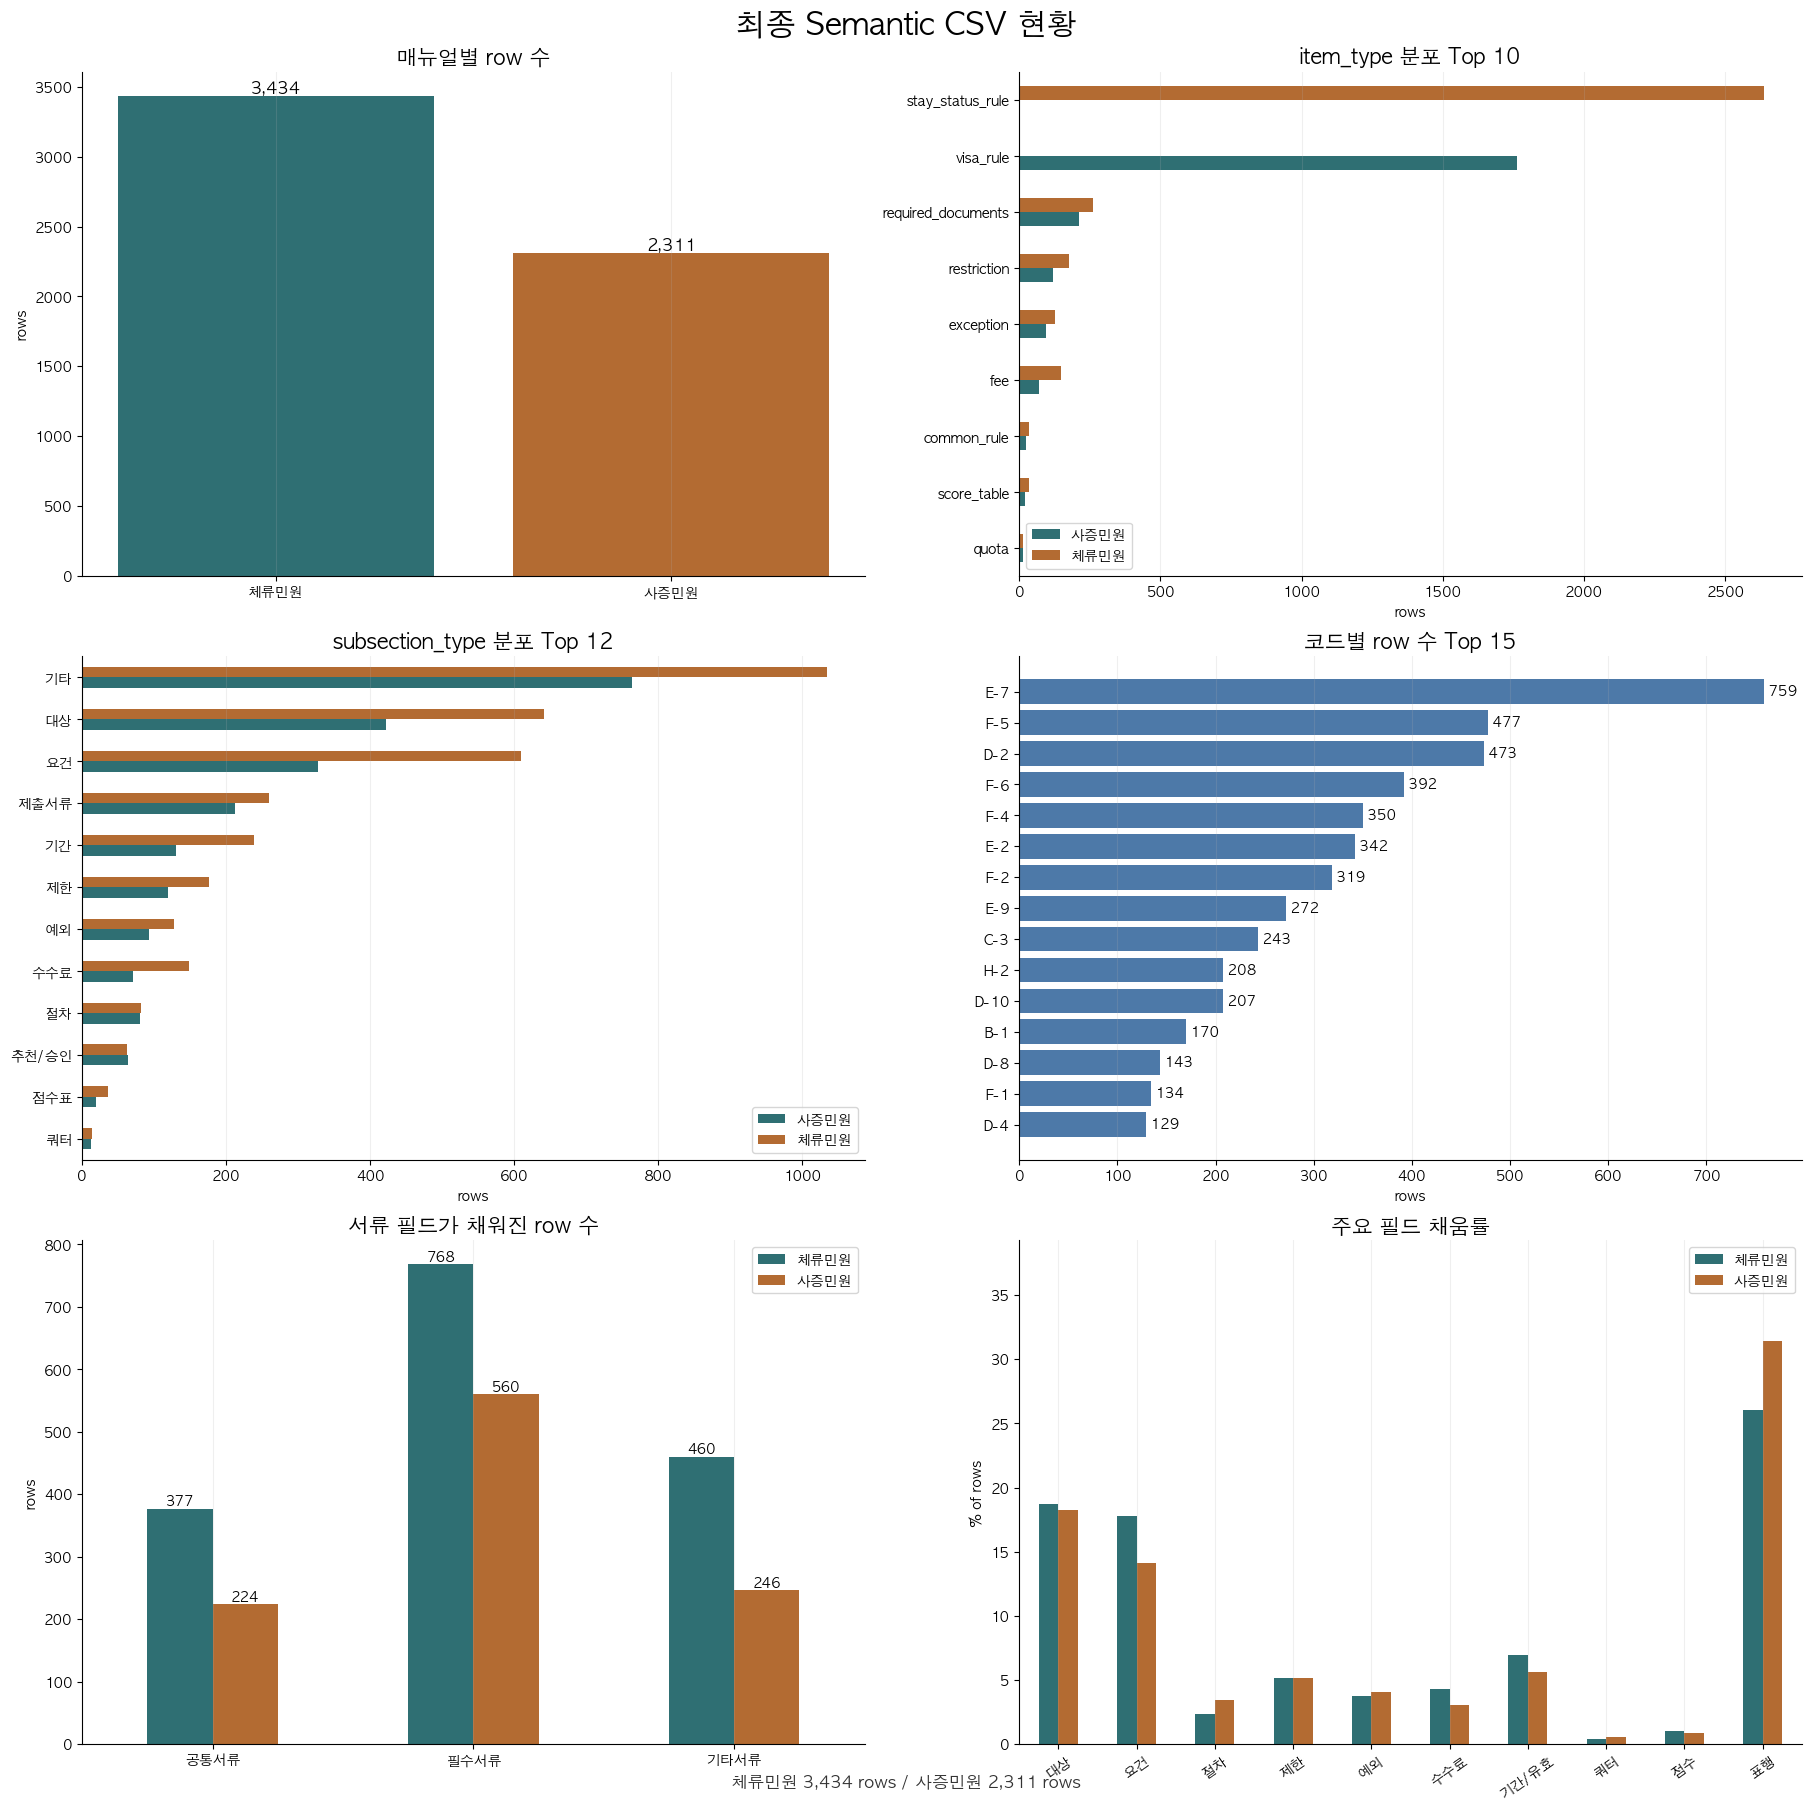

In [10]:
colors = ['#2f6f73', '#b36b32']
fig, axes = plt.subplots(3, 2, figsize=(18, 18), constrained_layout=True)
fig.suptitle('최종 Semantic CSV 현황', fontsize=22, fontweight='bold')

manual_counts = combined['manual'].value_counts().reindex(['체류민원', '사증민원'])
ax = axes[0, 0]
bars = ax.bar(manual_counts.index, manual_counts.values, color=colors)
ax.set_title('매뉴얼별 row 수', fontsize=15, fontweight='bold')
ax.set_ylabel('rows')
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{int(b.get_height()):,}', ha='center', va='bottom', fontsize=12)

ax = axes[0, 1]
item_counts = combined.pivot_table(index='item_type', columns='manual', aggfunc='size', fill_value=0)
item_counts['total'] = item_counts.sum(axis=1)
item_counts = item_counts.sort_values('total', ascending=True).drop(columns='total').tail(10)
item_counts.plot(kind='barh', ax=ax, color=colors)
ax.set_title('item_type 분포 Top 10', fontsize=15, fontweight='bold')
ax.set_xlabel('rows')
ax.set_ylabel('')
ax.legend(title='')

ax = axes[1, 0]
sub_counts = combined.pivot_table(index='subsection_type', columns='manual', aggfunc='size', fill_value=0)
sub_counts['total'] = sub_counts.sum(axis=1)
sub_counts = sub_counts.sort_values('total', ascending=True).drop(columns='total').tail(12)
sub_counts.plot(kind='barh', ax=ax, color=colors)
ax.set_title('subsection_type 분포 Top 12', fontsize=15, fontweight='bold')
ax.set_xlabel('rows')
ax.set_ylabel('')
ax.legend(title='')

ax = axes[1, 1]
code_counts = combined[combined['code'] != '공통/무코드']['code'].value_counts().head(15).sort_values()
ax.barh(code_counts.index, code_counts.values, color='#4d79a8')
ax.set_title('코드별 row 수 Top 15', fontsize=15, fontweight='bold')
ax.set_xlabel('rows')
ax.set_ylabel('')
for y, v in enumerate(code_counts.values):
    ax.text(v, y, f' {int(v):,}', va='center', fontsize=10)

ax = axes[2, 0]
doc_cols = ['common_documents', 'mandatory_documents', 'other_documents']
doc_labels = ['공통서류', '필수서류', '기타서류']
doc_data = pd.DataFrame({
    '체류민원': [(stay[c].str.strip() != '').sum() for c in doc_cols],
    '사증민원': [(visa[c].str.strip() != '').sum() for c in doc_cols],
}, index=doc_labels)
doc_data.plot(kind='bar', ax=ax, color=colors, rot=0)
ax.set_title('서류 필드가 채워진 row 수', fontsize=15, fontweight='bold')
ax.set_ylabel('rows')
ax.legend(title='')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10)

ax = axes[2, 1]
fields = ['eligibility', 'requirements', 'procedure', 'restrictions', 'exceptions', 'fees', 'duration_or_validity', 'quota_or_limit', 'score_criteria', 'table_rows']
field_labels = ['대상', '요건', '절차', '제한', '예외', '수수료', '기간/유효', '쿼터', '점수', '표행']
rate = pd.DataFrame({
    '체류민원': [(stay[f].str.strip() != '').mean() * 100 for f in fields],
    '사증민원': [(visa[f].str.strip() != '').mean() * 100 for f in fields],
}, index=field_labels)
rate.plot(kind='bar', ax=ax, color=colors, rot=35)
ax.set_title('주요 필드 채움률', fontsize=15, fontweight='bold')
ax.set_ylabel('% of rows')
ax.set_ylim(0, max(10, rate.to_numpy().max() * 1.25))
ax.legend(title='')

for ax in axes.ravel():
    ax.grid(axis='x', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

fig.text(0.5, 0.01, f'체류민원 {len(stay):,} rows / 사증민원 {len(visa):,} rows', ha='center', fontsize=12, color='#333333')
plt.show()

## 4. Subsection과 item_type 교차 분석

In [12]:
item_subsection = pd.crosstab(combined['subsection_type'], combined['item_type'])
item_subsection.loc[item_subsection.sum(axis=1).sort_values(ascending=False).index].head(15)

item_type,common_rule,exception,fee,quota,required_documents,restriction,score_table,stay_status_rule,visa_rule
subsection_type,,,,,,,,,
기타,21,0,0,0,0,0,0,1025,753
대상,14,0,0,0,0,0,0,631,419
요건,20,0,0,0,0,0,0,599,318
제출서류,0,0,0,0,472,0,0,0,0
기간,2,0,0,0,0,0,0,237,129
제한,0,0,0,0,0,295,0,0,0
예외,0,221,0,0,0,0,0,0,0
수수료,0,0,218,0,0,0,0,0,0
절차,0,0,0,0,0,0,0,81,80


## 5. 민원 유형 분포

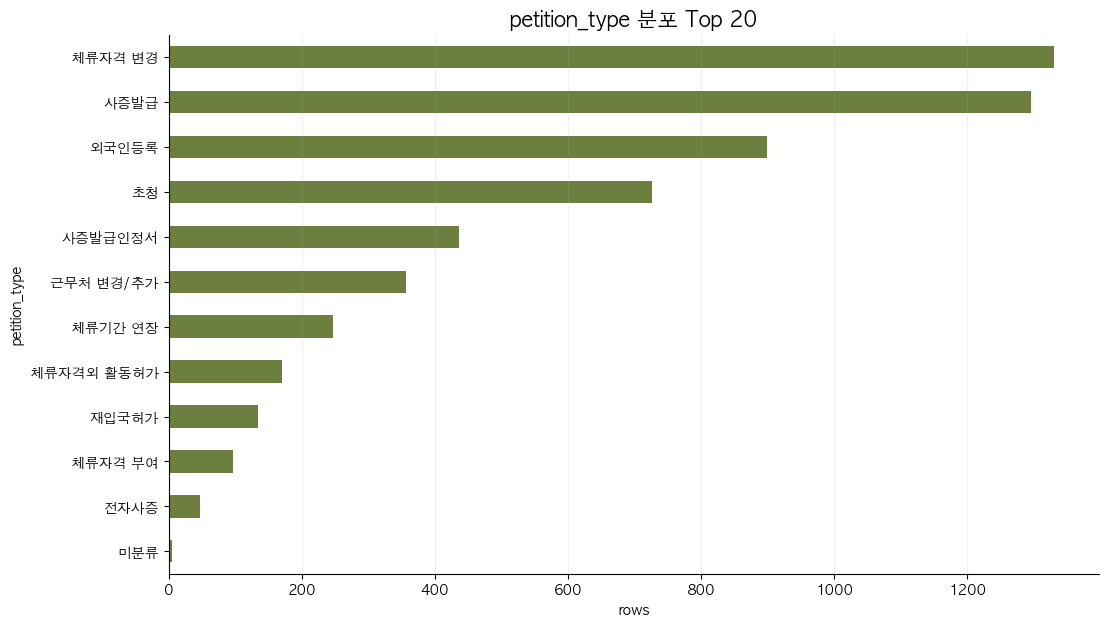

,rows
petition_type,
체류자격 변경,1331
사증발급,1296
외국인등록,899
초청,726
사증발급인정서,437
근무처 변경/추가,356
체류기간 연장,247
체류자격외 활동허가,171
재입국허가,134


In [14]:
petition_counts = combined['petition_type'].replace('', '미분류').value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 7))
petition_counts.sort_values().plot(kind='barh', ax=ax, color='#6d7f3f')
ax.set_title('petition_type 분포 Top 20', fontsize=15, fontweight='bold')
ax.set_xlabel('rows')
ax.grid(axis='x', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
plt.show()
petition_counts.to_frame('rows')

## 6. 주요 코드별 subsection 분포

많이 등장하는 코드가 어떤 항목으로 구성되어 있는지 봅니다.

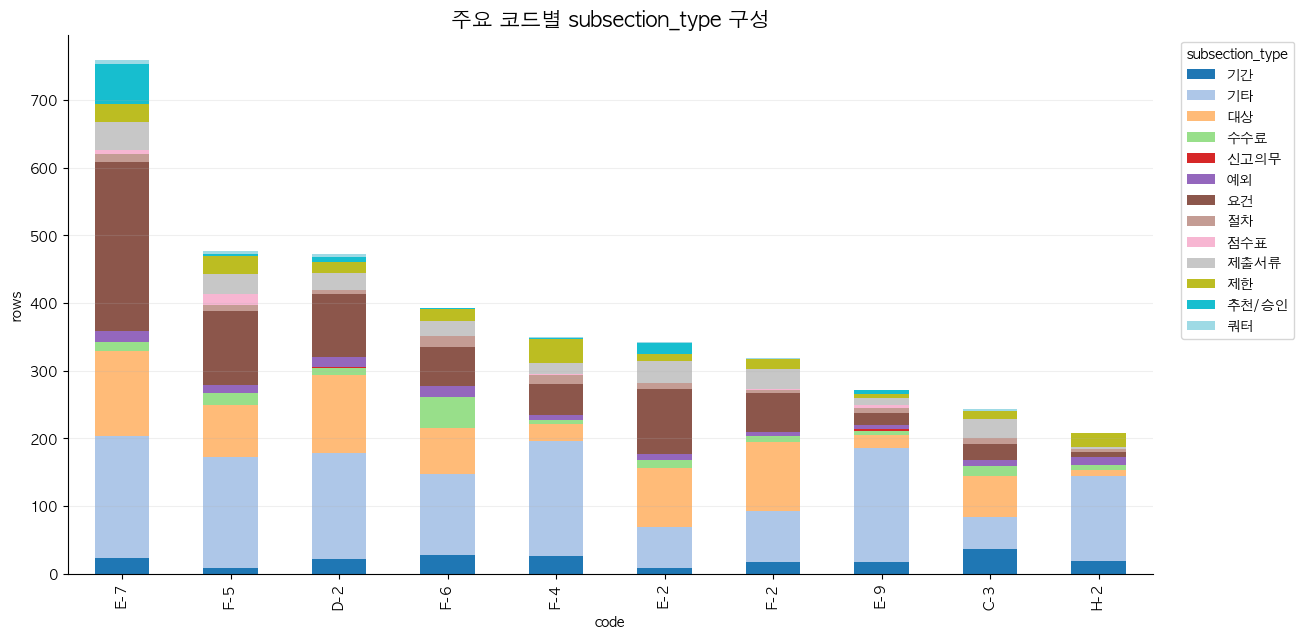

subsection_type,기간,기타,대상,수수료,신고의무,예외,요건,절차,점수표,제출서류,제한,추천/승인,쿼터
code,,,,,,,,,,,,,
E-7,23,180,126,13,0,17,249,12,6,42,27,59,5
F-5,9,163,78,17,0,12,109,9,16,30,26,4,4
D-2,21,157,115,11,1,15,93,7,0,25,16,7,5
F-6,28,120,68,45,0,17,57,16,1,22,17,1,0
F-4,26,170,25,6,0,7,46,14,1,17,35,2,1
E-2,8,61,87,12,0,9,96,9,0,32,10,17,1
F-2,17,75,102,10,0,6,57,4,2,29,15,1,1
E-9,17,169,19,6,3,6,17,8,4,10,7,5,1
C-3,37,47,60,15,0,9,23,9,0,28,12,1,2


In [17]:
top_codes = combined.loc[combined['code'] != '공통/무코드', 'code'].value_counts().head(10).index
code_subsection = pd.crosstab(combined.loc[combined['code'].isin(top_codes), 'code'], combined.loc[combined['code'].isin(top_codes), 'subsection_type'])
code_subsection = code_subsection.loc[top_codes]

fig, ax = plt.subplots(figsize=(14, 7))
code_subsection.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('주요 코드별 subsection_type 구성', fontsize=15, fontweight='bold')
ax.set_ylabel('rows')
ax.set_xlabel('code')
ax.legend(title='subsection_type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
plt.show()
code_subsection

## 7. 자동 품질검사 결과

`quality_report_semantic_manual_csvs.py`가 만든 검수 후보와 요약 리포트를 읽어 확인합니다. 파일이 없으면 현재 커널의 Python으로 스크립트를 먼저 실행합니다.

In [ ]:
quality_script = ROOT / 'scripts' / 'quality_report_semantic_manual_csvs.py'
report_path = QUALITY_DIR / 'semantic_manual_quality_report.md'
if not report_path.exists():
    subprocess.run([sys.executable, str(quality_script)], cwd=ROOT, check=True)

quality_summary = pd.concat(
    [
        pd.read_csv(QUALITY_DIR / 'stay_manual_quality_summary.csv', dtype=str).assign(manual='stay'),
        pd.read_csv(QUALITY_DIR / 'visa_manual_quality_summary.csv', dtype=str).assign(manual='visa'),
    ],
    ignore_index=True,
)
stay_candidates = pd.read_csv(QUALITY_DIR / 'stay_manual_review_candidates.csv', dtype=str).fillna('')
visa_candidates = pd.read_csv(QUALITY_DIR / 'visa_manual_review_candidates.csv', dtype=str).fillna('')
review_counts = pd.DataFrame(
    [
        {'manual': 'stay', 'candidate_count': len(stay_candidates), **stay_candidates['review_priority'].value_counts().to_dict()},
        {'manual': 'visa', 'candidate_count': len(visa_candidates), **visa_candidates['review_priority'].value_counts().to_dict()},
    ]
).fillna(0)

for priority in ['high', 'medium', 'low']:
    if priority not in review_counts.columns:
        review_counts[priority] = 0
    review_counts[priority] = pd.to_numeric(review_counts[priority], errors='coerce').fillna(0).astype(int)

review_counts['candidate_count'] = pd.to_numeric(review_counts['candidate_count'], errors='coerce').fillna(0).astype(int)

display(quality_summary)
display(review_counts[['manual', 'candidate_count', 'high', 'medium', 'low']])

priority_cols = ['high', 'medium', 'low']
if review_counts[priority_cols].to_numpy().sum() == 0:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.text(0.5, 0.5, 'No review candidates', ha='center', va='center', fontsize=14)
    ax.axis('off')
    plt.show()
else:
    ax = review_counts.set_index('manual')[priority_cols].plot(kind='bar', stacked=True, figsize=(8, 4), color=['#c45454', '#b36b32', '#6d7f3f'])
    ax.set_title('Review Candidates by Priority')
    ax.set_xlabel('')
    ax.set_ylabel('Rows')
    ax.legend(title='priority')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 8. 검수 후보 샘플

사람이 먼저 확인해야 할 후보 행입니다. 전체 행은 `output/review/*_manual_review.xlsx`의 `all_rows_with_flags` 시트에서 필터링할 수 있습니다.

In [ ]:
candidate_cols = ['source_row_number', 'review_priority', 'review_reason', 'suggested_action', 'item_type', 'section_title', 'petition_type', 'subsection_type', 'normalized_text']
print('stay candidates:', len(stay_candidates))
display(stay_candidates[[col for col in candidate_cols if col in stay_candidates.columns]].head(20))
print('visa candidates:', len(visa_candidates))
display(visa_candidates[[col for col in candidate_cols if col in visa_candidates.columns]].head(20))

## 9. 누락률/채움률 테이블

In [20]:
analysis_fields = ['common_documents', 'mandatory_documents', 'other_documents', 'eligibility', 'target_persons', 'requirements', 'procedure', 'restrictions', 'exceptions', 'fees', 'duration_or_validity', 'quota_or_limit', 'score_criteria', 'table_rows', 'normalized_text']
fill_table = pd.DataFrame({
    '체류민원_fill_rate_%': [(stay[c].str.strip() != '').mean() * 100 for c in analysis_fields],
    '사증민원_fill_rate_%': [(visa[c].str.strip() != '').mean() * 100 for c in analysis_fields],
}, index=analysis_fields).round(1)
fill_table

,체류민원_fill_rate_%,사증민원_fill_rate_%
common_documents,11.0,9.7
mandatory_documents,22.4,24.2
other_documents,13.4,10.6
eligibility,18.7,18.3
target_persons,18.7,18.3
requirements,17.8,14.1
procedure,2.4,3.5
restrictions,5.1,5.1
exceptions,3.7,4.0
fees,4.3,3.0


## 10. 검토용 샘플 보기

필수서류, 대상, 요건 row를 일부 확인합니다.

In [22]:
sample_cols = ['manual', 'code', 'item_type', 'subsection_type', 'petition_type', 'section_title', 'mandatory_documents', 'eligibility', 'requirements', 'normalized_text']
combined.loc[combined['subsection_type'].isin(['제출서류', '대상', '요건']), sample_cols].head(30)

,manual,code,item_type,subsection_type,petition_type,section_title,mandatory_documents,eligibility,requirements,normalized_text
1,체류민원,공통/무코드,required_documents,제출서류,,각종 체류허가 신청 시 유의사항 체류자격별 대상 및 제출서류 등 안내매뉴얼,각종 체류허가 신청 시 유의사항 체류자격별 대상 및 제출서류 등 안내매뉴얼; 공통사...,,,각종 체류허가 신청 시 유의사항 체류자격별 대상 및 제출서류 등 안내매뉴얼; 공통사...
4,체류민원,공통/무코드,required_documents,제출서류,,유 의 사 항,# 유 의 사 항; ※ 출입국·외국인청(사무소·출장소)장은 심사를 위해 특히 필요하...,,,# 유 의 사 항; ※ 출입국·외국인청(사무소·출장소)장은 심사를 위해 특히 필요하...
6,체류민원,공통/무코드,required_documents,제출서류,체류자격 변경,3. 제출 서류 중 분량이 많은 서류는 이를 발췌하여 사용하는 등 필요 없는 서류를...,제출 서류 중 분량이 많은 서류는 이를 발췌하여 사용하는 등 필요 없는 서류를 제출...,,,제출 서류 중 분량이 많은 서류는 이를 발췌하여 사용하는 등 필요 없는 서류를 제출...
9,체류민원,A-1,stay_status_rule,대상,체류자격 변경,적용대상,,"적용대상; 아래 외국인을 제외한 모든 장기 체류자격 외국인; 외교(A-1), 공무(...",,"적용대상; 아래 외국인을 제외한 모든 장기 체류자격 외국인; 외교(A-1), 공무(..."
10,체류민원,공통/무코드,stay_status_rule,요건,근무처 변경/추가,"체류자격 부여, 체류기간 연장 , 체류자격 변경, 근무처 변경·추가 민원업무에 적용",,,"체류자격 부여, 체류기간 연장 , 체류자격 변경, 근무처 변경·추가 민원업무에 적용...","체류자격 부여, 체류기간 연장 , 체류자격 변경, 근무처 변경·추가 민원업무에 적용..."
15,체류민원,C-4,stay_status_rule,대상,외국인등록,- 국내에 90일 초과하여 체류할 목적으로 사증을 신청하는 경우(전자사증 대상자의 ...,,국내에 90일 초과하여 체류할 목적으로 사증을 신청하는 경우(전자사증 대상자의 경우...,,국내에 90일 초과하여 체류할 목적으로 사증을 신청하는 경우(전자사증 대상자의 경우...
16,체류민원,공통/무코드,stay_status_rule,대상,체류자격 변경,◯ 외국인등록 시,,외국인등록 시; 사증 신청 시 결핵진단서를 제출해야하는 외국인이 전자사증으로 입국한...,,외국인등록 시; 사증 신청 시 결핵진단서를 제출해야하는 외국인이 전자사증으로 입국한...
19,체류민원,A-1,stay_status_rule,요건,체류자격외 활동허가,- 해당 체류자격별 체류자격외 활동 필요서류(자격요건 등 구비),,,해당 체류자격별 체류자격외 활동 필요서류(자격요건 등 구비),해당 체류자격별 체류자격외 활동 필요서류(자격요건 등 구비)
20,체류민원,A-1,required_documents,제출서류,체류자격외 활동허가,※ 주한미국대사관 공관원가족에 대한 제출서류 간소화('22.1.17.),※ 주한미국대사관 공관원가족에 대한 제출서류 간소화('22.1.17.); 취업업체의...,,,※ 주한미국대사관 공관원가족에 대한 제출서류 간소화('22.1.17.); 취업업체의...
22,체류민원,A-1,stay_status_rule,대상,체류자격외 활동허가,○ 적용대상,,적용대상; 대한민국과 협정을 체결하여 국내에 주소지를 둔 국제기구에서 외교(A-1)...,,적용대상; 대한민국과 협정을 체결하여 국내에 주소지를 둔 국제기구에서 외교(A-1)...


## 11. 차트 파일 저장

In [ ]:
# 위 대시보드를 파일로 저장하고 싶을 때 이 셀을 실행하세요.
# 노트북에 표시된 figure와 별도로 재생성하여 저장합니다.

output_path = FIG_DIR / 'semantic_csv_overview.png'
print('저장 위치:', output_path)
# 대시보드 셀을 실행한 뒤 아래 한 줄을 별도 figure 저장 코드로 바꿔도 됩니다.
# fig.savefig(output_path, dpi=180, bbox_inches='tight')